# 42 - Undersampling Neutral: Mengatasi Imbalance

**Masalah:** Neutral mendominasi 78% training, 95% test. Imbalance ratio 36.8:1 (4-class).

**Strategi:** Kurangi neutral di training set, test set tetap sama (fair comparison).

| Variasi | Neutral Train | Total Train | Rasio Neutral:Negative |
|---------|:------------:|:-----------:|:---------------------:|
| Original | 4,192 | 5,348 | 36.8:1 |
| **Under-660** | 660 | 1,816 | **5.8:1** |
| **Under-382** | 382 | 1,538 | **3.4:1** |
| **Under-114** | 114 | 1,270 | **1:1** |

**Model:** Top 3 (Intermediate TL, Late Fusion, FCNN) — 4-class, B1 Baseline
**Evaluasi:** Single split (test set identik)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import (
    EmotionCNN, EmotionFCNN, IntermediateFusion,
    EmotionCNNTransfer, IntermediateFusionTransfer,
)
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    train_model, full_evaluation,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "undersampled"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

DATASETS = {
    "original": PROJECT_ROOT / "data" / "dataset_frontonly_4class",
    "under_660": PROJECT_ROOT / "data" / "dataset_frontonly_under_660_4class",
    "under_382": PROJECT_ROOT / "data" / "dataset_frontonly_under_382_4class",
    "under_114": PROJECT_ROOT / "data" / "dataset_frontonly_under_114_4class",
}

for name, path in DATASETS.items():
    y = np.load(path / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"  {name}: {len(y)} train | {dict(sorted(counts.items()))}")

print("\nSetup complete.")

Device: cuda
GPU: Tesla T4
  original: 5348 train | {0: 4192, 1: 660, 2: 382, 3: 114}
  under_660: 1816 train | {0: 660, 1: 660, 2: 382, 3: 114}
  under_382: 1538 train | {0: 382, 1: 660, 2: 382, 3: 114}
  under_114: 1270 train | {0: 114, 1: 660, 2: 382, 3: 114}

Setup complete.


## Helper Functions

In [2]:
def load_loaders(dataset_dir, model_type, batch_size=32):
    if model_type == "cnn":
        DS = EmotionImageDataset
        train = DS(dataset_dir/"X_train_images.npy", dataset_dir/"y_train.npy")
        val = DS(dataset_dir/"X_val_images.npy", dataset_dir/"y_val.npy")
        test = DS(dataset_dir/"X_test_images.npy", dataset_dir/"y_test.npy")
    elif model_type == "fcnn":
        DS = EmotionLandmarkDataset
        train = DS(dataset_dir/"X_train_landmarks.npy", dataset_dir/"y_train.npy")
        val = DS(dataset_dir/"X_val_landmarks.npy", dataset_dir/"y_val.npy")
        test = DS(dataset_dir/"X_test_landmarks.npy", dataset_dir/"y_test.npy")
    else:
        DS = EmotionMultimodalDataset
        train = DS(dataset_dir/"X_train_images.npy", dataset_dir/"X_train_landmarks.npy", dataset_dir/"y_train.npy")
        val = DS(dataset_dir/"X_val_images.npy", dataset_dir/"X_val_landmarks.npy", dataset_dir/"y_val.npy")
        test = DS(dataset_dir/"X_test_images.npy", dataset_dir/"X_test_landmarks.npy", dataset_dir/"y_test.npy")
    return (DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
            DataLoader(val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
            DataLoader(test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True))


def run_experiment(name, ModelClass, model_type, lr, dataset_dir):
    train_l, val_l, test_l = load_loaders(dataset_dir, model_type, BATCH_SIZE)
    model = ModelClass(num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    save_path = str(OUTPUT_DIR / f"{name}.pth")

    print(f"\n>> {name}")
    train_model(model, train_l, val_l, criterion, optimizer, scheduler,
                device, model_type, EPOCHS, PATIENCE, save_path)
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    r = full_evaluation(model, test_l, criterion, device, model_type, EMOTIONS)
    print(f"   Acc={r['test_accuracy']:.4f} Macro-F1={r['test_macro_f1']:.4f}")

    # Per-class report
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_l:
            if model_type == "fusion":
                images, landmarks, labels = batch
                outputs = model(images.to(device), landmarks.to(device))
            elif model_type == "cnn":
                images, labels = batch
                outputs = model(images.to(device))
            else:
                landmarks, labels = batch
                outputs = model(landmarks.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=EMOTIONS, zero_division=0))

    return {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
        "per_class": classification_report(all_labels, all_preds, target_names=EMOTIONS, output_dict=True, zero_division=0),
    }


def late_fusion_experiment(name, dataset_dir):
    train_img, val_img, test_img = load_loaders(dataset_dir, "cnn", BATCH_SIZE)
    train_lm, val_lm, test_lm = load_loaders(dataset_dir, "fcnn", BATCH_SIZE)
    test_mm_l = load_loaders(dataset_dir, "fusion", BATCH_SIZE)[2]

    # Train CNN
    cnn = EmotionCNN(num_classes=NUM_CLASSES).to(device)
    opt1 = torch.optim.Adam(cnn.parameters(), lr=0.0001)
    sch1 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    train_model(cnn, train_img, val_img, nn.CrossEntropyLoss(), opt1, sch1,
                device, "cnn", EPOCHS, PATIENCE, str(OUTPUT_DIR/f"{name}_cnn.pth"))

    # Train FCNN
    fcnn = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
    opt2 = torch.optim.Adam(fcnn.parameters(), lr=0.0001)
    sch2 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    train_model(fcnn, train_lm, val_lm, nn.CrossEntropyLoss(), opt2, sch2,
                device, "fcnn", EPOCHS, PATIENCE, str(OUTPUT_DIR/f"{name}_fcnn.pth"))

    cnn.load_state_dict(torch.load(OUTPUT_DIR/f"{name}_cnn.pth", map_location=device, weights_only=True))
    fcnn.load_state_dict(torch.load(OUTPUT_DIR/f"{name}_fcnn.pth", map_location=device, weights_only=True))
    cnn.eval(); fcnn.eval()

    cnn_probs, fcnn_probs, labels_all = [], [], []
    with torch.no_grad():
        for images, landmarks, labels in test_mm_l:
            cnn_probs.append(torch.softmax(cnn(images.to(device)), dim=1).cpu().numpy())
            fcnn_probs.append(torch.softmax(fcnn(landmarks.to(device)), dim=1).cpu().numpy())
            labels_all.append(labels.numpy())
    cp = np.concatenate(cnn_probs); fp = np.concatenate(fcnn_probs); lbls = np.concatenate(labels_all)

    best_f1, best_w = 0, 0.5
    for w in np.arange(0.0, 1.05, 0.05):
        preds = (w*cp+(1-w)*fp).argmax(axis=1)
        f1 = f1_score(lbls, preds, average="macro", zero_division=0)
        if f1 > best_f1: best_f1=f1; best_w=w; best_preds=preds

    acc = accuracy_score(lbls, best_preds)
    wf1 = f1_score(lbls, best_preds, average="weighted", zero_division=0)
    print(f"\n>> {name} (w={best_w:.2f})")
    print(f"   Acc={acc:.4f} Macro-F1={best_f1:.4f}")
    print(classification_report(lbls, best_preds, target_names=EMOTIONS, zero_division=0))

    return {"accuracy": acc, "macro_f1": best_f1, "weighted_f1": wf1, "best_cnn_weight": best_w,
            "per_class": classification_report(lbls, best_preds, target_names=EMOTIONS, output_dict=True, zero_division=0)}

print("Helper functions ready.")

Helper functions ready.


## Run Experiments

In [3]:
all_results = {}

for ds_name, ds_path in DATASETS.items():
    print(f"\n{'='*70}")
    print(f"  DATASET: {ds_name}")
    print(f"{'='*70}")

    # Intermediate TL
    r = run_experiment(f"IntTL_{ds_name}", IntermediateFusionTransfer, "fusion", 0.00005, ds_path)
    all_results[f"IntTL_{ds_name}"] = r

    # FCNN
    r = run_experiment(f"FCNN_{ds_name}", EmotionFCNN, "fcnn", 0.0001, ds_path)
    all_results[f"FCNN_{ds_name}"] = r

    # Late Fusion
    r = late_fusion_experiment(f"LateFusion_{ds_name}", ds_path)
    all_results[f"LateFusion_{ds_name}"] = r


  DATASET: original



>> IntTL_original
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1652     0.5245     0.8737    0.9052   0.2379   0.000050  (19.6s)


     2      0.7275     0.7868     0.6071    0.9194   0.4164   0.000050  (19.3s)


     3      0.5688     0.8280     0.4829    0.9095   0.3606   0.000050  (19.2s)


...

    47      0.7942     0.7087     1.3553    0.3423   0.2336   0.000050  (0.6s)


    48      0.7541     0.7244     1.4748    0.2772   0.1644   0.000050  (0.7s)


    49      0.7590     0.7102     1.5447    0.2037   0.1250   0.000050  (0.7s)


    50      0.7482     0.7213     1.5874    0.2249   0.1346   0.000025  (0.6s)

Best: epoch 40, val_acc=0.2702, val_f1=0.2354
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/undersampled/LateFusion_under_114_fcnn.pth



>> LateFusion_under_114 (w=0.25)
   Acc=0.3581 Macro-F1=0.1602
              precision    recall  f1-score   support

     neutral       0.97      0.35      0.52       981
       happy       0.01      0.10      0.01        10
         sad       0.06      0.86      0.12        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.36      1036
   macro avg       0.26      0.33      0.16      1036
weighted avg       0.92      0.36      0.49      1036



## Ringkasan

In [4]:
print("="*80)
print("RINGKASAN UNDERSAMPLING EXPERIMENTS")
print("="*80)

models = ["IntTL", "FCNN", "LateFusion"]
ds_names = ["original", "under_660", "under_382", "under_114"]

for model in models:
    print(f"\n  {model}:")
    print(f"  {'Dataset':<15} {'Macro F1':>10} {'Acc':>10} {'neutral':>10} {'happy':>10} {'sad':>10} {'negative':>10}")
    print(f"  {'-'*75}")
    for ds in ds_names:
        key = f"{model}_{ds}"
        if key in all_results:
            r = all_results[key]
            pc = r.get("per_class", {})
            print(f"  {ds:<15} {r['macro_f1']:>10.4f} {r['accuracy']:>10.4f}"
                  f" {pc.get('neutral',{}).get('f1-score',0):>10.3f}"
                  f" {pc.get('happy',{}).get('f1-score',0):>10.3f}"
                  f" {pc.get('sad',{}).get('f1-score',0):>10.3f}"
                  f" {pc.get('negative',{}).get('f1-score',0):>10.3f}")

# Save
with open(OUTPUT_DIR / "undersampled_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)
print(f"\nSaved: {OUTPUT_DIR / 'undersampled_results.json'}")

RINGKASAN UNDERSAMPLING EXPERIMENTS

  IntTL:
  Dataset           Macro F1        Acc    neutral      happy        sad   negative
  ---------------------------------------------------------------------------
  original            0.3628     0.9459      0.975      0.000      0.476      0.000
  under_660           0.2571     0.8600      0.934      0.068      0.027      0.000
  under_382           0.3222     0.8485      0.933      0.059      0.197      0.100
  under_114           0.2771     0.7876      0.889      0.118      0.019      0.083

  FCNN:
  Dataset           Macro F1        Acc    neutral      happy        sad   negative
  ---------------------------------------------------------------------------
  original            0.2631     0.8832      0.940      0.112      0.000      0.000
  under_660           0.3477     0.9093      0.954      0.095      0.341      0.000
  under_382           0.2646     0.8504      0.921      0.037      0.100      0.000
  under_114           0.3431     

## Visualisasi Per-Class F1

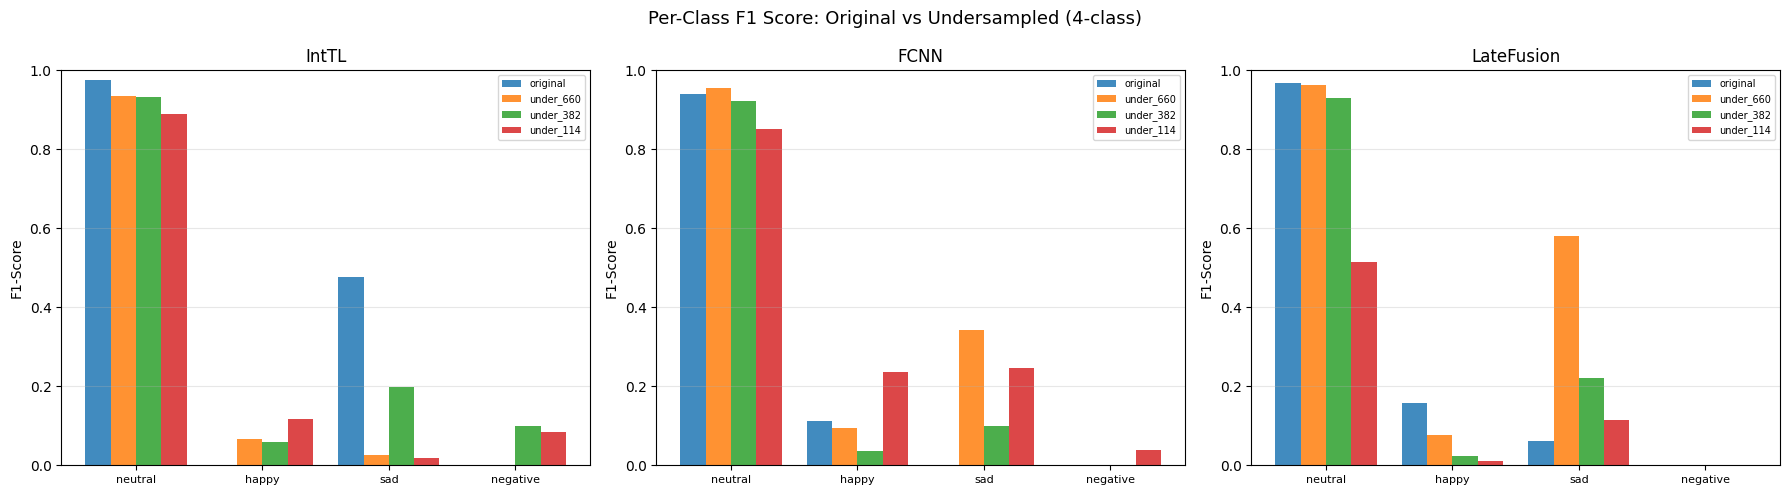

Chart saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/undersampled/undersampled_perclass.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model in zip(axes, models):
    x = np.arange(len(EMOTIONS))
    width = 0.2
    for i, ds in enumerate(ds_names):
        key = f"{model}_{ds}"
        if key not in all_results: continue
        pc = all_results[key].get("per_class", {})
        vals = [pc.get(emo, {}).get("f1-score", 0) for emo in EMOTIONS]
        ax.bar(x + i*width, vals, width, label=ds, alpha=0.85)

    ax.set_ylabel("F1-Score")
    ax.set_title(model)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(EMOTIONS, fontsize=8)
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Per-Class F1 Score: Original vs Undersampled (4-class)", fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "undersampled_perclass.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {OUTPUT_DIR / 'undersampled_perclass.png'}")